In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/diabetic_data.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (101766, 50)

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
# Check shape, column names, and data types
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values (? counts):")
for col in df.columns:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count} missing (?)")
print("\nTarget Variable Distribution:")
print(df['readmitted'].value_counts())

Shape: (101766, 50)

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:
encounter_id                int64
patient_nbr                 int64
race                          str
gender                        st

In [3]:
print("Missing Values (? counts):")
for col in df.columns:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count}")

Missing Values (? counts):
  race: 2273
  weight: 98569
  payer_code: 40256
  medical_specialty: 49949
  diag_1: 21
  diag_2: 358
  diag_3: 1423


In [4]:
# Drop columns with too many missing values
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'])

# Replace ? with Unknown
df['race'] = df['race'].replace('?', 'Unknown')
df['diag_1'] = df['diag_1'].replace('?', 'Unknown')
df['diag_2'] = df['diag_2'].replace('?', 'Unknown')
df['diag_3'] = df['diag_3'].replace('?', 'Unknown')

# Remove invalid gender rows
df = df[df['gender'] != 'Unknown/Invalid']

# Each patient appears multiple times - keep only first encounter
df = df.sort_values('encounter_id')
df = df.drop_duplicates(subset='patient_nbr', keep='first')

print("Shape after cleaning:", df.shape)
print("\nAny ? remaining:", (df == '?').any().any())

Shape after cleaning: (71515, 47)

Any ? remaining: False


In [5]:
# Convert target variable
# We'll predict: did the patient get readmitted? (Yes/No)
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

print("Target distribution:")
print(df['readmitted_binary'].value_counts())
print("\nReadmission rate:", df['readmitted_binary'].mean().round(3))

# Convert age range to numeric midpoint
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_map)

print("\nAge numeric sample:")
print(df[['age', 'age_numeric']].head(5))

Target distribution:
readmitted_binary
0    42982
1    28533
Name: count, dtype: int64

Readmission rate: 0.399

Age numeric sample:
         age  age_numeric
8    [80-90)           85
9   [90-100)           95
4    [40-50)           45
10   [40-50)           45
5    [50-60)           55


In [6]:
# Medication columns - how many medications was the patient on?
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone']

# Count how many medications were active (not "No")
df['num_active_meds'] = (df[med_cols] != 'No').sum(axis=1)

# Was insulin prescribed?
df['on_insulin'] = (df['insulin'] != 'No').astype(int)

# Was any medication changed during visit?
df['med_changed'] = (df['change'] == 'Ch').astype(int)

# Total visits before this encounter
df['total_prior_visits'] = (df['number_outpatient'] + 
                             df['number_emergency'] + 
                             df['number_inpatient'])

# Is this a high utilizer? (3+ prior visits)
df['high_utilizer'] = (df['total_prior_visits'] >= 3).astype(int)

print("New features sample:")
print(df[['num_active_meds', 'on_insulin', 'med_changed', 
          'total_prior_visits', 'high_utilizer']].head())
print("\nHigh utilizers:", df['high_utilizer'].sum())

New features sample:
    num_active_meds  on_insulin  med_changed  total_prior_visits  \
8                 2           1            1                   0   
9                 2           1            1                   0   
4                 2           1            1                   0   
10                1           1            0                   0   
5                 1           1            0                   0   

    high_utilizer  
8               0  
9               0  
4               0  
10              0  
5               0  

High utilizers: 4831


In [7]:
from sklearn.preprocessing import LabelEncoder

# Select final feature columns
feature_cols = [
    # Demographics
    'age_numeric', 'race', 'gender',
    # Hospital visit info
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_diagnoses',
    # Prior visits
    'number_outpatient', 'number_emergency', 'number_inpatient',
    'total_prior_visits', 'high_utilizer',
    # Diabetes specific
    'num_active_meds', 'on_insulin', 'med_changed',
    'max_glu_serum', 'A1Cresult',
    # Admission info
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id'
]

# Create model dataframe
model_df = df[feature_cols + ['readmitted_binary']].copy()

# Convert text columns to numbers using LabelEncoder
text_cols = ['race', 'gender', 'max_glu_serum', 'A1Cresult']
le = LabelEncoder()
for col in text_cols:
    model_df[col] = le.fit_transform(model_df[col])

print("Final dataset shape:", model_df.shape)
print("\nData types:")
print(model_df.dtypes)
print("\nSample:")
print(model_df.head(3))

Final dataset shape: (71515, 22)

Data types:
age_numeric                 int64
race                        int64
gender                      int64
time_in_hospital            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_diagnoses            int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
total_prior_visits          int64
high_utilizer               int64
num_active_meds             int64
on_insulin                  int64
med_changed                 int64
max_glu_serum               int64
A1Cresult                   int64
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
readmitted_binary           int64
dtype: object

Sample:
   age_numeric  race  gender  time_in_hospital  num_lab_procedures  \
8           85     2       0                13                  68   
9           95     2       0               

In [8]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = model_df.drop(columns=['readmitted_binary'])
y = model_df['readmitted_binary']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)
print("\nTarget balance in training set:")
print(y_train.value_counts())

Training set: (57212, 21)
Testing set:  (14303, 21)

Target balance in training set:
readmitted_binary
0    34386
1    22826
Name: count, dtype: int64


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Train Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print(f"Logistic Regression AUC: {lr_auc:.4f}")

# Train Random Forest
print("\nTraining Random Forest (takes 1-2 mins)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"Random Forest AUC: {rf_auc:.4f}")

print("\nBest model:", "Random Forest" if rf_auc > lr_auc else "Logistic Regression")

Training Logistic Regression...
Logistic Regression AUC: 0.6137

Training Random Forest (takes 1-2 mins)...
Random Forest AUC: 0.6361

Best model: Random Forest


Top 10 Most Important Features:
                 feature  importance
      num_lab_procedures    0.177317
         num_medications    0.148553
        time_in_hospital    0.098240
             age_numeric    0.076238
          num_procedures    0.067240
        number_diagnoses    0.064365
discharge_disposition_id    0.059784
         num_active_meds    0.042943
       admission_type_id    0.037566
                    race    0.035911


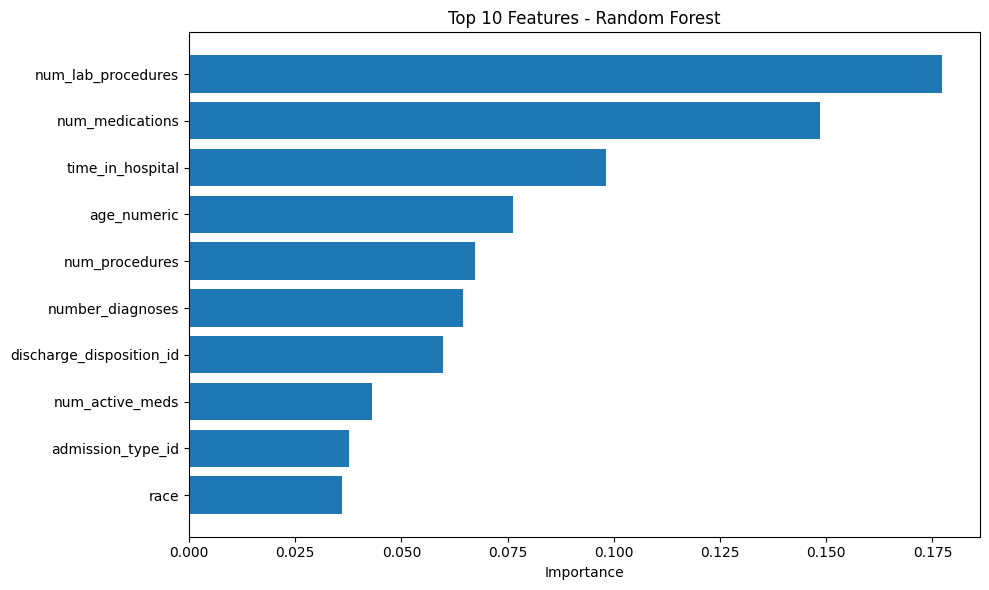


Chart saved to models/feature_importance.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance['feature'].head(10)[::-1], 
         importance['importance'].head(10)[::-1])
plt.xlabel('Importance')
plt.title('Top 10 Features - Random Forest')
plt.tight_layout()
plt.savefig('../models/feature_importance.png')
plt.show()
print("\nChart saved to models/feature_importance.png")

MODEL EVALUATION

Confusion Matrix:
                 Predicted NO  Predicted YES
Actual NO              6951         1645
Actual YES             3719         1988

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.65      0.81      0.72      8596
    Readmitted       0.55      0.35      0.43      5707

      accuracy                           0.62     14303
     macro avg       0.60      0.58      0.57     14303
  weighted avg       0.61      0.62      0.60     14303



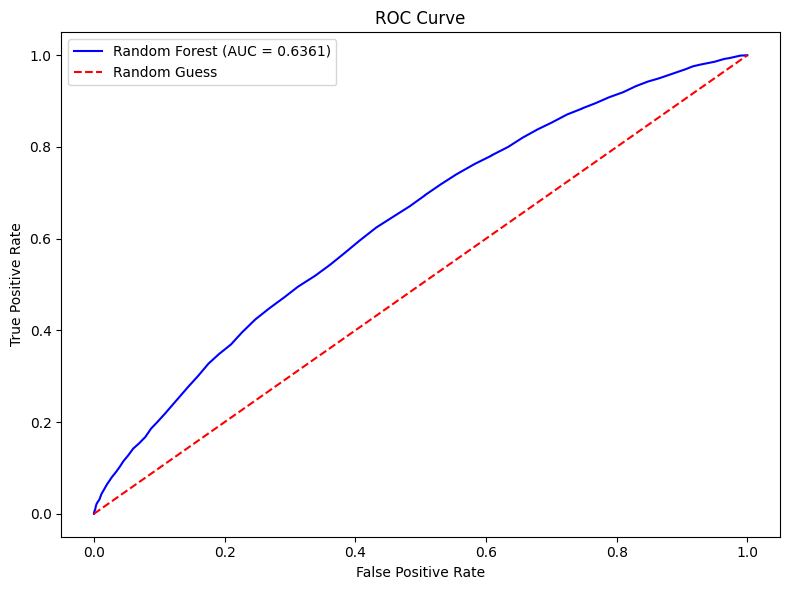

In [13]:
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                 Predicted NO  Predicted YES")
print(f"Actual NO        {cm[0][0]:>10}   {cm[0][1]:>10}")
print(f"Actual YES       {cm[1][0]:>10}   {cm[1][1]:>10}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Not Readmitted', 'Readmitted']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../models/roc_curve.png')
plt.show()

MODEL IMPROVISATION

In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Random Forest with balanced class weight
print("Training improved Random Forest...")
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)
rf_bal_auc = roc_auc_score(y_test, rf_balanced.predict_proba(X_test)[:,1])
print(f"Balanced Random Forest AUC: {rf_bal_auc:.4f}")

# Gradient Boosting
print("\nTraining Gradient Boosting...")
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)
gb_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])
print(f"Gradient Boosting AUC: {gb_auc:.4f}")

# Compare all models
print("\n--- Model Comparison ---")
print(f"Logistic Regression  : {lr_auc:.4f}")
print(f"Random Forest        : {rf_auc:.4f}")
print(f"Balanced Random Forest: {rf_bal_auc:.4f}")
print(f"Gradient Boosting    : {gb_auc:.4f}")

Training improved Random Forest...
Balanced Random Forest AUC: 0.6550

Training Gradient Boosting...
Gradient Boosting AUC: 0.6616

--- Model Comparison ---
Logistic Regression  : 0.6137
Random Forest        : 0.6361
Balanced Random Forest: 0.6550
Gradient Boosting    : 0.6616


In [15]:
import pickle
import json

# Save best model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(gb, f)

# Save feature columns
with open('../models/feature_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

# Save metrics
metrics = {
    'best_model': 'Gradient Boosting',
    'auc': round(gb_auc, 4),
    'logistic_regression_auc': round(lr_auc, 4),
    'random_forest_auc': round(rf_auc, 4),
    'balanced_random_forest_auc': round(rf_bal_auc, 4),
    'gradient_boosting_auc': round(gb_auc, 4),
    'n_train': len(X_train),
    'n_test': len(X_test),
    'n_features': len(X_train.columns),
    'trained_at': str(pd.Timestamp.now())
}

with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ Model saved!")
print("✅ Feature columns saved!")
print("✅ Metrics saved!")
print("\nMetrics:")
print(json.dumps(metrics, indent=2))

✅ Model saved!
✅ Feature columns saved!
✅ Metrics saved!

Metrics:
{
  "best_model": "Gradient Boosting",
  "auc": 0.6616,
  "logistic_regression_auc": 0.6137,
  "random_forest_auc": 0.6361,
  "balanced_random_forest_auc": 0.655,
  "gradient_boosting_auc": 0.6616,
  "n_train": 57212,
  "n_test": 14303,
  "n_features": 21,
  "trained_at": "2026-03-11 14:22:27.544351"
}
